In [ ]:
import os
if not os.path.exists("ai-solution-pubmed-qa"):
    !git clone https://github.com/realhenrycheng/AITA_Coursework_Team11.git

Cloning into 'AITA_Coursework_Team11'...
remote: Enumerating objects: 346, done.
remote: Counting objects: 100% (137/137), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 346 (delta 64), reused 106 (delta 51), pack-reused 209 (from 1)
Receiving objects: 100% (346/346), 38.73 MiB | 11.78 MiB/s, done.
Resolving deltas: 100% (141/141), done.
Updating files: 100% (96/96), done.


### 1. Import and Label definition

In [ ]:
import os
import json
import random
from pathlib import Path
import sys
sys.path.append('./AITA_Coursework_Team11')
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from pubmed_loader import PubMedQAData
from evaluation_plot import evaluate, plot_confusion_matrix, get_error_samples, get_errors_by_type
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [ ]:
LABEL_NAMES = {"yes": 0, "no": 1, "maybe": 2}
LABEL_NAMES_INV = {0: "yes", 1: "no", 2: "maybe"}

In [ ]:
RANDOM_SEED = 11

In [ ]:
def set_all_seeds(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    print(f"All seeds set to {seed}")
set_all_seeds()

All seeds set to 11


### 2. Path setup

In [ ]:
DATA_DIR = Path("AITA_Coursework_Team11/data")

In [ ]:
FOLD_DIR = DATA_DIR / "pqal_fold0"

In [ ]:
FOLD_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
required_files = {
    Path("train_set.json"): FOLD_DIR / "train_set.json",
    Path("dev_set.json"): FOLD_DIR / "dev_set.json",
    Path("test_set.json"): DATA_DIR / "test_set.json",
    Path("test_ground_truth.json"): DATA_DIR / "test_ground_truth.json",
}

In [ ]:
for source_path, target_path in required_files.items():
    if source_path.exists() and not target_path.exists():
        target_path.write_bytes(source_path.read_bytes())
        print(f"Copied {source_path} -> {target_path}")
print(f"Using data directory: {DATA_DIR.resolve()}")

Using data directory: /content/AITA_Coursework_Team11/data


### 3. Data Loading

In [ ]:
data = PubMedQAData("AITA_Coursework_Team11/data")
print(f"train: {len(data.train_set)} samples")
print(f"dev:   {len(data.dev_set)} samples")
print(f"test:  {len(data.test_set)} samples")
print(f"test labels: {len(data.test_ground_truth)} labels")

train: 450 samples
dev:   50 samples
test:  500 samples
test labels: 500 labels


### 4. PubMedBERT Input Preparation

In [ ]:
MODEL_NAME = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"
MAX_LENGTH = 512
BATCH_SIZE = 8
USE_MESH = True
POOLING = "mean"
OUTPUT_DIR = Path("outputs") / "pubmedbert_svm"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Model:", MODEL_NAME)
print("Max length:", MAX_LENGTH)
print("Batch size:", BATCH_SIZE)
print("Use MeSH:", USE_MESH)
print("Pooling:", POOLING)

Model: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Max length: 512
Batch size: 8
Use MeSH: True
Pooling: mean


In [ ]:
def build_question_context(sample, use_mesh=False):
    question = sample["QUESTION"]
    context = " ".join(sample["CONTEXTS"])
    if use_mesh:
        context += " " + " ".join(sample.get("MESHES", []))
    return question, context
def make_pubmedbert_inputs(dataset, use_mesh=False):
    pmids = []
    questions = []
    contexts = []
    for pmid, sample in dataset.items():
        question, context = build_question_context(sample, use_mesh=use_mesh)
        pmids.append(pmid)
        questions.append(question)
        contexts.append(context)
    return pmids, questions, contexts
def labels_from_dataset(dataset):
    return [LABEL_NAMES[sample["final_decision"].lower().strip()] for sample in dataset.values()]
def labels_from_ground_truth(pmids, ground_truth):
    return [LABEL_NAMES[ground_truth[pmid].lower().strip()] for pmid in pmids]

In [ ]:
train_pmids, train_questions, train_contexts = make_pubmedbert_inputs(data.train_set, use_mesh=USE_MESH)
train_labels = labels_from_dataset(data.train_set)
dev_pmids, dev_questions, dev_contexts = make_pubmedbert_inputs(data.dev_set, use_mesh=USE_MESH)
dev_labels = labels_from_dataset(data.dev_set)
test_pmids, test_questions, test_contexts = make_pubmedbert_inputs(data.test_set, use_mesh=USE_MESH)
test_labels = labels_from_ground_truth(test_pmids, data.test_ground_truth)
print(f"train: {len(train_questions)} samples")
print(f"dev:   {len(dev_questions)} samples")
print(f"test:  {len(test_questions)} samples")

train: 450 samples
dev:   50 samples
test:  500 samples


In [ ]:
print("Train:", np.bincount(train_labels, minlength=3))
print("Dev:  ", np.bincount(dev_labels, minlength=3))
print("Test: ", np.bincount(test_labels, minlength=3))

Train: [249 152  49]
Dev:   [27 17  6]
Test:  [276 169  55]


In [ ]:
combined_questions = train_questions + dev_questions
combined_contexts = train_contexts + dev_contexts
combined_labels = train_labels + dev_labels
y_train = np.array(combined_labels)
y_test = np.array(test_labels)
print(f"combined train+dev: {len(combined_questions)} samples")

combined train+dev: 500 samples


### 5. Load PubMedBERT and Extract Embeddings

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
promedbert_model = AutoModel.from_pretrained(MODEL_NAME)
promedbert_model.to(device)
promedbert_model.eval()
print(f"Using device: {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using device: cpu


In [ ]:
def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts
def extract_pubmedbert_embeddings(questions, contexts, batch_size=BATCH_SIZE, max_length=MAX_LENGTH, pooling=POOLING):
    vectors = []
    for start in tqdm(range(0, len(questions), batch_size), desc="Extracting PubMedBERT embeddings"):
        batch_questions = questions[start:start + batch_size]
        batch_contexts = contexts[start:start + batch_size]
        encoded = tokenizer(
            batch_questions,
            batch_contexts,
            max_length=max_length,
            truncation="only_second",
            padding=True,
            return_tensors="pt"
        )
        encoded = {key: value.to(device) for key, value in encoded.items()}
        with torch.no_grad():
            outputs = pubmedbert_model(**encoded)
        if pooling == "cls":
            pooled = outputs.last_hidden_state[:, 0, :]
        else:
            pooled = mean_pooling(outputs.last_hidden_state, encoded["attention_mask"])
        vectors.append(pooled.detach().cpu().numpy())
    return np.vstack(vectors)

In [ ]:
cache_suffix = f"mesh_{USE_MESH}_pool_{POOLING}_max_{MAX_LENGTH}"
train_cache = OUTPUT_DIR / f"train_dev_embeddings_{cache_suffix}.npy"
test_cache = OUTPUT_DIR / f"test_embeddings_{cache_suffix}.npy"
if train_cache.exists() and test_cache.exists():
    X_train = np.load(train_cache)
    X_test = np.load(test_cache)
    print("Loaded cached PubMedBERT embeddings.")
else:
    X_train = extract_pubmedbert_embeddings(combined_questions, combined_contexts)
    X_test = extract_pubmedbert_embeddings(test_questions, test_contexts)
    np.save(train_cache, X_train)
    np.save(test_cache, X_test)
    print("Saved PubMedBERT embeddings to cache.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

Extracting PubMedBERT embeddings:   0%|          | 0/63 [00:00<?, ?it/s]

Extracting PubMedBERT embeddings:   0%|          | 0/63 [00:00<?, ?it/s]

Saved PubMedBERT embeddings to cache.
X_train shape: (500, 768)
X_test shape:  (500, 768)


### 6. Support Vector Machine (SVM)

Hyperparameter tuning with 5-fold cross-validation.

In [ ]:
param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
grid_search = GridSearchCV(
    SVC(
        class_weight="balanced",
        probability=True,
        random_state=RANDOM_SEED
    ),
    param_grid,
    cv=cv,
    scoring="f1_macro",
    verbose=1,
    n_jobs=4
)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=11, shuffle=True),
             estimator=SVC(class_weight='balanced', probability=True,
                           random_state=11),
             n_jobs=4,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             scoring='f1_macro', verbose=1)

In [ ]:
def print_grid_search_summary(grid_search, top_n=5):
    results_df = pd.DataFrame(grid_search.cv_results_)
    cols = ["params", "mean_test_score", "std_test_score", "rank_test_score"]
    summary = results_df[cols].sort_values(by="rank_test_score")
    print(f"Top {top_n} Hyperparameter Combinations")
    print(summary.head(top_n).to_string(index=False))
print_grid_search_summary(grid_search)

Top 5 Hyperparameter Combinations
                                          params  mean_test_score  std_test_score  rank_test_score
   {'C': 1, 'gamma': 'auto', 'kernel': 'linear'}         0.414529        0.035099                1
  {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}         0.414529        0.035099                1
  {'C': 10, 'gamma': 'auto', 'kernel': 'linear'}         0.380254        0.023430                3
 {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}         0.380254        0.023430                3
{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}         0.363492        0.035425                5


Select the best model.

In [ ]:
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score (F1): {grid_search.best_score_:.4f}")
best_svm = grid_search.best_estimator_

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Score (F1): 0.4145


### 7. Evaluation

In [ ]:
y_pred = best_svm.predict(X_test)
evaluate(y_pred, y_test, "Test_set")


── Test_set ──
Accuracy: 0.5040  Macro-F1: 0.4206
              precision    recall  f1-score   support

         yes       0.63      0.59      0.61       276
          no       0.42      0.46      0.44       169
       maybe       0.21      0.22      0.21        55

    accuracy                           0.50       500
   macro avg       0.42      0.42      0.42       500
weighted avg       0.51      0.50      0.51       500



==== Error Analysis ====

True=yes (total=276, correct=162, error=114):
   Predicted no: 88/276 (31.9%)
   Predicted maybe: 26/276 (9.4%)

True=no (total=169, correct=78, error=91):
   Predicted yes: 72/169 (42.6%)
   Predicted maybe: 19/169 (11.2%)

True=maybe (total=55, correct=12, error=43):
   Predicted yes: 25/55 (45.5%)
   Predicted no: 18/55 (32.7%)


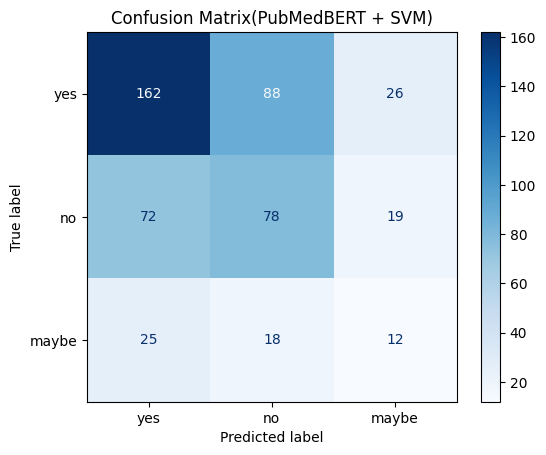

In [ ]:
plot_confusion_matrix(y_test, y_pred, title="PubMedBERT + SVM")

In [ ]:
test_accuracy = accuracy_score(y_test, y_pred)
test_macro_f1 = f1_score(y_test, y_pred, average="macro")
results_df = pd.DataFrame([
    {
        "method": "PubMedBERT + SVM",
        "representation": "PubMedBERT mean-pooled embeddings",
        "classifier": "SVM",
        "use_mesh": USE_MESH,
        "pooling": POOLING,
        "best_params": str(grid_search.best_params_),
        "cv_macro_f1": grid_search.best_score_,
        "test_accuracy": test_accuracy,
        "test_macro_f1": test_macro_f1,
    }
])
results_df

,method,representation,classifier,use_mesh,pooling,best_params,cv_macro_f1,test_accuracy,test_macro_f1
0,PubMedBERT + SVM,PubMedBERT mean-pooled embeddings,SVM,True,mean,"{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}",0.414529,0.504,0.420607


### 8. Error Analysis

In [ ]:
get_error_samples(data, y_test, y_pred, n=5)


Error samples (top 5)

PMID: 12377809
Question : Is anorectal endosonography valuable in dyschesia?
True     : yes
Predicted: no

PMID: 18537964
Question : Does a physician's specialty influence the recording of medication history in patients' case notes?
True     : yes
Predicted: no

PMID: 25475395
Question : Is there a correlation between androgens and sexual desire in women?
True     : yes
Predicted: no

PMID: 24481006
Question : Should cavitation in proximal surfaces be reported in cone beam computed tomography examination?
True     : yes
Predicted: no

PMID: 20629769
Question : Is primary angioplasty an acceptable alternative to thrombolysis?
True     : yes
Predicted: maybe


In [ ]:
get_errors_by_type(data, y_test, y_pred, true_class="maybe", pred_class="yes", n=3)

True=maybe  Predicted=yes  (total 25 errors, showing 3)
  Question: Expression of c-kit protooncogen in hepatitis B virus-induced chronic hepatitis, cirrhosis and hepatocellular carcinoma: has it a diagnostic role?
  Context: ['Paraffin-embedded tissues in Cukurova University Faculty of Medicine Department of Pathology between January 2002 and February 2006 were searched restrospectively to investigate this issue. We performed immunohistochemistry on biopsies of 125 patients with HBV infection, grouped as: mild, moderate and severe hepatitis, cirrhosis and HCC, 25 patients in each of them, using anti c-kit monoclonal antibody. The severity of parenchymal inflammation and of interface hepatitis was semiquantitatively graded on a haematoxylin and eosin stained paraffin sections. Additionally, 50 more HCC, formed on HBV basis, were studied to determine the prevalence of c-kit overexpression.', 'In cirrhotic liver, lower intensity of staining and rarely c-kit positivity were present. The g

In [ ]:
get_errors_by_type(data, y_test, y_pred, true_class="no", pred_class="yes", n=3)

True=no  Predicted=yes  (total 72 errors, showing 3)
  Question: Does strategy training reduce age-related deficits in working memory?
  Context: ['Older adults typically perform worse on measures of working memory (WM) than do young adults; however, age-related differences in WM performance might be reduced if older adults use effective encoding strategies.', 'The purpose of the current experiment was to evaluate WM performance after training individuals to use effective encoding strategies.', 'Participants in the training group (older adults: n = 39; young adults: n = 41) were taught about various verbal encoding strategies and their differential effectiveness and were trained to use interactive imagery and sentence generation on a list-learning task. Participants in the control group (older: n = 37; young: n = 38) completed an equally engaging filler task. All participants completed a pre- and post-training reading span task, which included self-reported strategy use, as well as two

In [ ]:
error_rows = []
for i, (pmid, sample) in enumerate(data.test_set.items()):
    if y_test[i] != y_pred[i]:
        error_rows.append({
            "pmid": pmid,
            "question": sample["QUESTION"],
            "true_label": LABEL_NAMES_INV[int(y_test[i])],
            "predicted_label": LABEL_NAMES_INV[int(y_pred[i])],
            "year": sample.get("YEAR", None),
            "context_preview": " ".join(sample["CONTEXTS"])[:500]
        })
error_df = pd.DataFrame(error_rows)
error_df.head()

,pmid,question,true_label,predicted_label,year,context_preview
0,12377809,Is anorectal endosonography valuable in dysche...,yes,no,2002,Dyschesia can be provoked by inappropriate def...
1,18537964,Does a physician's specialty influence the rec...,yes,no,2008,To determine the impact of a physician's speci...
2,25475395,Is there a correlation between androgens and s...,yes,no,2015,"For women, the correlation between circulating..."
3,24481006,Should cavitation in proximal surfaces be repo...,yes,no,2014,79 adjacent proximal surfaces without restorat...
4,20629769,Is primary angioplasty an acceptable alternati...,yes,maybe,2010,The National Infarct Angioplasty Project asses...


### 9. Save Predictions and Results

In [ ]:
prediction_dict = {
    pmid: LABEL_NAMES_INV[int(pred)]
    for pmid, pred in zip(test_pmids, y_pred)
}
prediction_path = OUTPUT_DIR / "pubmedbert_svm_predictions.json"
result_path = OUTPUT_DIR / "pubmedbert_svm_results.csv"
error_path = OUTPUT_DIR / "pubmedbert_svm_error_analysis.csv"
with open(prediction_path, "w", encoding="utf-8") as f:
    json.dump(prediction_dict, f, indent=2)
results_df.to_csv(result_path, index=False)
error_df.to_csv(error_path, index=False)
print(f"Saved predictions to: {prediction_path}")
print(f"Saved results to:     {result_path}")
print(f"Saved errors to:      {error_path}")

Saved predictions to: outputs/pubmedbert_svm/pubmedbert_svm_predictions.json
Saved results to:     outputs/pubmedbert_svm/pubmedbert_svm_results.csv
Saved errors to:      outputs/pubmedbert_svm/pubmedbert_svm_error_analysis.csv
